<a href="https://colab.research.google.com/github/mahidi07/badminton-pose-analysis/blob/main/04_stgcn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04 - ST-GCN Model Training
**Project:** Automated Pose-Based Analysis of Badminton Player Movements Using Deep Learning  
**Student:** Mahidi Ilangarathna (14486346)  
**Supervisor:** A/Prof. Nabin Sharma, UTS  

---

### What this notebook does

1. Connects to ClearML for experiment tracking
2. Loads the saved keypoint arrays and adjacency matrix from Drive
3. Builds the ST-GCN input tensors in the correct (N, C, T, V) format
4. Implements the ST-GCN architecture from scratch
5. Trains the model with the same train/val/test split used for the LSTM baseline
6. Evaluates and produces accuracy, F1-score, and confusion matrix
7. Directly compares ST-GCN results against the saved LSTM baseline
8. Saves the best ST-GCN checkpoint to Drive

### Why ST-GCN over LSTM

The LSTM treats each frame as a flat vector of 51 numbers and processes them sequentially. It has no understanding that joint 9 (left wrist) and joint 7 (left elbow) are physically connected, or that those two joints together define the arm configuration during a smash. ST-GCN explicitly models those anatomical relationships through the graph structure, which is why it consistently outperforms flat sequence models on skeleton-based action recognition tasks.

**Input format difference:**
- LSTM input: `(batch, 30, 51)` - flattened sequence
- ST-GCN input: `(batch, 3, 30, 17)` - channels, time, joints

**Before running:** Confirm Notebook 03 has been run and the following files exist in Drive:
- `data/keypoints/` - all .npy clip arrays
- `data/coco_adjacency_matrix.npy` - saved by Notebook 03
- `models/lstm_baseline_best.pt` - used for comparison at the end

---
## Section 1 - ClearML Credentials

Paste your credentials here. Clear them before saving to GitHub.

In [1]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=GA7TDAQYE9TKEA7JSN584EF15584EO
%env CLEARML_API_SECRET_KEY=XaAWr-EvkTPi21bvQFIk2xXeNGS1DUVT-mDZGTi37KkFFGsX5dfHpjWtu1FfaEqRfvg

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=GA7TDAQYE9TKEA7JSN584EF15584EO
env: CLEARML_API_SECRET_KEY=XaAWr-EvkTPi21bvQFIk2xXeNGS1DUVT-mDZGTi37KkFFGsX5dfHpjWtu1FfaEqRfvg


---
## Section 2 - Install Libraries and Check GPU

In [2]:
!pip install clearml scikit-learn -q
print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.1 MB/s eta 0:00:00
Libraries installed.


In [3]:
import torch

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    DEVICE = torch.device('cuda')
else:
    print("No GPU. Go to Runtime > Change runtime type > T4 GPU.")
    DEVICE = torch.device('cpu')

print("Device:", DEVICE)

GPU: Tesla T4
Device: cuda


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
from clearml import Task

print("All imports OK")

All imports OK


---
## Section 3 - Mount Drive and Configuration

In [5]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


In [6]:
BASE          = '/content/drive/MyDrive/14486346_Honours'
KEYPOINTS_DIR = os.path.join(BASE, 'data/keypoints')
MODELS_DIR    = os.path.join(BASE, 'models')
OUTPUTS_DIR   = os.path.join(BASE, 'outputs')
ADJ_PATH      = os.path.join(BASE, 'data/coco_adjacency_matrix.npy')
LSTM_CKPT     = os.path.join(MODELS_DIR, 'lstm_baseline_best.pt')

for d in [MODELS_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ST-GCN hyperparameters
# These are deliberately close to the LSTM hparams where equivalent
# so the comparison is as fair as possible
HPARAMS = {
    'target_frames'      : 30,
    'num_joints'         : 17,
    'in_channels'        : 3,        # x, y, confidence
    'base_channels'      : 64,       # feature channels in first GCN layer
    'num_gcn_layers'     : 9,        # standard ST-GCN uses 9 layers
    'dropout'            : 0.5,
    'learning_rate'      : 1e-3,
    'weight_decay'       : 1e-4,
    'batch_size'         : 32,
    'num_epochs'         : 80,
    'train_split'        : 0.70,
    'val_split'          : 0.15,
    'test_split'         : 0.15,
    'random_seed'        : 42,       # same seed as Notebook 03 for identical splits
    'use_weighted_sampler': True,
    'label_smoothing'    : 0.1,      # reduces overconfidence on similar classes
}

random.seed(HPARAMS['random_seed'])
np.random.seed(HPARAMS['random_seed'])
torch.manual_seed(HPARAMS['random_seed'])

print("Config set.")
for k, v in HPARAMS.items():
    print(f"  {k:<25} {v}")

Config set.
  target_frames             30
  num_joints                17
  in_channels               3
  base_channels             64
  num_gcn_layers            9
  dropout                   0.5
  learning_rate             0.001
  weight_decay              0.0001
  batch_size                32
  num_epochs                80
  train_split               0.7
  val_split                 0.15
  test_split                0.15
  random_seed               42
  use_weighted_sampler      True
  label_smoothing           0.1


---
## Section 4 - Initialise ClearML Task

In [7]:
task = Task.init(
    project_name = 'BadmintonPoseAnalysis',
    task_name    = f'STGCN-ch{HPARAMS["base_channels"]}-lr{HPARAMS["learning_rate"]}-e{HPARAMS["num_epochs"]}',
    tags         = ['stgcn', 'notebook-04']
)
task.connect(HPARAMS)
logger = task.get_logger()

print("ClearML task initialised.")
print("View at: https://app.clear.ml")

ClearML Task: created new task id=c9e6e6763ed946019e9f0f3fb86c9312


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-04-16 13:43:39,224 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/experiments/c9e6e6763ed946019e9f0f3fb86c9312/output/log
ClearML task initialised.
View at: https://app.clear.ml


---
## Section 5 - Load Dataset and Adjacency Matrix

In [8]:
# Load adjacency matrix saved by Notebook 03
if not os.path.exists(ADJ_PATH):
    raise FileNotFoundError(f"Adjacency matrix not found at {ADJ_PATH}. Run Notebook 03 first.")

A = np.load(ADJ_PATH)   # (17, 17) row-normalised
A_tensor = torch.tensor(A, dtype=torch.float32).to(DEVICE)
print(f"Adjacency matrix loaded: {A.shape}")

# Load all keypoint arrays
npy_files = sorted(Path(KEYPOINTS_DIR).rglob('*.npy'))
if not npy_files:
    raise FileNotFoundError(f"No .npy files in {KEYPOINTS_DIR}. Run Notebooks 01 and 02 first.")

class_names  = sorted(set(p.parent.name for p in npy_files))
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}
NUM_CLASSES  = len(class_names)

X, y = [], []
for npy_path in npy_files:
    try:
        arr = np.load(npy_path).astype(np.float32)   # (30, 17, 3)
        X.append(arr)
        y.append(class_to_idx[npy_path.parent.name])
    except Exception as e:
        print(f"Skipped {npy_path.name}: {e}")

X = np.stack(X)   # (N, 30, 17, 3)
y = np.array(y)

print(f"Loaded {len(X)} clips across {NUM_CLASSES} classes.")
print(f"X shape: {X.shape}")
print()
print("Class distribution:")
counts = Counter(y)
for idx in sorted(counts):
    print(f"  [{idx:>2}] {idx_to_class[idx]:<30} {counts[idx]:>4}")

Adjacency matrix loaded: (17, 17)
Loaded 1882 clips across 18 classes.
X shape: (1882, 30, 17, 3)

Class distribution:
  [ 0] 00_Short Serve                  100
  [ 1] 01_Cross Court Flight           101
  [ 2] 02_Lift                         108
  [ 3] 03_Tap Smash                    101
  [ 4] 04_Block                        104
  [ 5] 05_Drop Shot                    109
  [ 6] 06_Push Shot                    109
  [ 7] 07_Transitional Slice           103
  [ 8] 08_Cut                          108
  [ 9] 09_Rush Shot                    102
  [10] 10_Defensive Clear              100
  [11] 11_Defensive Drive              100
  [12] 12_Clear                        108
  [13] 13_Long Serve                   109
  [14] 14_Smash                        108
  [15] 15_Flat Shot                    108
  [16] 16_Rear Court Flat Drive        101
  [17] 17_Short Flat Shot              103


---
## Section 6 - ST-GCN Dataset

ST-GCN expects input of shape `(N, C, T, V)` where:
- N = batch size
- C = input channels (3: x, y, confidence)
- T = temporal frames (30)
- V = number of joints (17)

This is different from the LSTM which used `(N, T, C*V)`. The reshape happens inside the Dataset.

In [9]:
class STGCNDataset(Dataset):
    """
    Converts keypoint arrays to the (C, T, V) format expected by ST-GCN.

    Input array shape  : (30, 17, 3)
    Output tensor shape: (3, 30, 17)  -- channels first, ready for ST-GCN
    """
    def __init__(self, X, y):
        # (N, T, V, C) -> (N, C, T, V)
        X_transposed = X.transpose(0, 3, 1, 2)
        self.X = torch.tensor(X_transposed, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Same splits and seed as Notebook 03 for a fair comparison
idx_all = np.arange(len(X))
idx_train, idx_temp = train_test_split(
    idx_all, test_size=(1 - HPARAMS['train_split']),
    stratify=y, random_state=HPARAMS['random_seed']
)
val_ratio = HPARAMS['val_split'] / (HPARAMS['val_split'] + HPARAMS['test_split'])
idx_val, idx_test = train_test_split(
    idx_temp, test_size=(1 - val_ratio),
    stratify=y[idx_temp], random_state=HPARAMS['random_seed']
)

train_dataset = STGCNDataset(X[idx_train], y[idx_train])
val_dataset   = STGCNDataset(X[idx_val],   y[idx_val])
test_dataset  = STGCNDataset(X[idx_test],  y[idx_test])

print(f"Split  ->  train: {len(train_dataset)}  val: {len(val_dataset)}  test: {len(test_dataset)}")
print(f"ST-GCN input shape per sample: {train_dataset[0][0].shape}  (C, T, V)")

# Weighted sampler
train_labels   = y[idx_train]
class_counts   = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights  = 1.0 / np.where(class_counts == 0, 1, class_counts)
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(train_dataset), replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=HPARAMS['batch_size'], sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=HPARAMS['batch_size'], shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=HPARAMS['batch_size'], shuffle=False)

print(f"Batch shape: ({HPARAMS['batch_size']}, 3, {HPARAMS['target_frames']}, {HPARAMS['num_joints']})")

Split  ->  train: 1317  val: 282  test: 283
ST-GCN input shape per sample: torch.Size([3, 30, 17])  (C, T, V)
Batch shape: (32, 3, 30, 17)


---
## Section 7 - ST-GCN Architecture

The implementation follows the original ST-GCN paper (Yan et al., 2018). Each ST-GCN layer applies a graph convolution across the joint dimension (spatial) followed by a temporal convolution across the frame dimension. Stacking 9 such layers allows the model to capture increasingly abstract movement patterns.

The adjacency matrix learned from Notebook 03 defines which joints can exchange information in each spatial convolution.

In [10]:
class GraphConv(nn.Module):
    """
    Single graph convolution layer.
    Aggregates features from neighbouring joints using the adjacency matrix.

    Input : (N, C_in, T, V)
    Output: (N, C_out, T, V)
    """
    def __init__(self, in_channels, out_channels, A):
        super().__init__()
        self.A    = A   # (V, V) adjacency matrix, kept on device
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.bn   = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        # x: (N, C, T, V)
        # Graph convolution: mix joint features using adjacency
        # einsum: for each (n, c, t), sum over v weighted by A[v, w]
        x = torch.einsum('nctv,vw->nctw', x, self.A)
        x = self.conv(x)
        x = self.bn(x)
        return x


class STGCNLayer(nn.Module):
    """
    One ST-GCN layer: spatial graph convolution followed by temporal convolution.

    Spatial: GraphConv mixes information across connected joints at each frame.
    Temporal: Conv2d with kernel (t_kernel, 1) mixes information across frames
              for each joint independently.

    A residual connection is included. If channel dimensions differ, a 1x1
    convolution projects the residual to the correct size.
    """
    def __init__(self, in_channels, out_channels, A,
                 stride=1, dropout=0.0, t_kernel=9):
        super().__init__()

        padding = (t_kernel - 1) // 2

        self.gcn = GraphConv(in_channels, out_channels, A)

        self.tcn = nn.Sequential(
            nn.Conv2d(out_channels, out_channels,
                      kernel_size=(t_kernel, 1),
                      stride=(stride, 1),
                      padding=(padding, 0)),
            nn.BatchNorm2d(out_channels),
        )

        # Residual projection if dimensions change
        if in_channels != out_channels or stride != 1:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.residual = nn.Identity()

        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU(inplace=True)

    def forward(self, x):
        res = self.residual(x)
        x   = self.gcn(x)
        x   = self.relu(x)
        x   = self.tcn(x)
        x   = self.dropout(x)
        return self.relu(x + res)


class STGCN(nn.Module):
    """
    Full ST-GCN model with 9 layers, following the channel progression
    from the original paper: 64, 64, 64, 128, 128, 128, 256, 256, 256.

    Input : (N, C_in, T, V)  e.g. (batch, 3, 30, 17)
    Output: (N, num_classes)

    Global average pooling over time and joints before the classifier
    makes the model robust to minor clip length variations.
    """
    def __init__(self, in_channels, num_classes, A, base_ch=64, dropout=0.5):
        super().__init__()

        self.bn_input = nn.BatchNorm1d(in_channels * A.shape[0])

        ch = base_ch
        # Layer channel progression: 64x3, 128x3, 256x3
        layer_configs = [
            (in_channels, ch,    1, 0.0),
            (ch,          ch,    1, 0.0),
            (ch,          ch,    1, 0.0),
            (ch,          ch*2,  1, dropout),
            (ch*2,        ch*2,  1, dropout),
            (ch*2,        ch*2,  1, dropout),
            (ch*2,        ch*4,  1, dropout),
            (ch*4,        ch*4,  1, dropout),
            (ch*4,        ch*4,  1, dropout),
        ]

        self.layers = nn.ModuleList([
            STGCNLayer(ic, oc, A, dropout=dp)
            for ic, oc, st, dp in layer_configs
        ])

        self.classifier = nn.Linear(ch * 4, num_classes)

    def forward(self, x):
        # Input normalisation
        N, C, T, V = x.shape
        x_flat = x.permute(0, 3, 1, 2).contiguous().view(N, V * C, T)
        # BN over the joint-channel dimension
        x_flat = self.bn_input(x_flat.view(N, V * C, -1))
        x = x_flat.view(N, V, C, T).permute(0, 2, 3, 1).contiguous()

        for layer in self.layers:
            x = layer(x)

        # Global average pool over time and joints: (N, C, T, V) -> (N, C)
        x = x.mean(dim=[2, 3])
        return self.classifier(x)


model = STGCN(
    in_channels = HPARAMS['in_channels'],
    num_classes = NUM_CLASSES,
    A           = A_tensor,
    base_ch     = HPARAMS['base_channels'],
    dropout     = HPARAMS['dropout']
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ST-GCN model built.")
print(f"Trainable parameters : {total_params:,}")
print(f"Number of classes    : {NUM_CLASSES}")
print(f"Input shape          : (batch, {HPARAMS['in_channels']}, {HPARAMS['target_frames']}, {HPARAMS['num_joints']})")

ST-GCN model built.
Trainable parameters : 2,590,904
Number of classes    : 18
Input shape          : (batch, 3, 30, 17)


---
## Section 8 - Loss, Optimiser, Scheduler

In [11]:
# Class-weighted loss with label smoothing
# Label smoothing (0.1) softens the target distribution slightly,
# which helps when some classes are visually similar
class_counts_all  = np.bincount(y, minlength=NUM_CLASSES).astype(np.float32)
class_weights_loss = torch.tensor(
    1.0 / np.where(class_counts_all == 0, 1, class_counts_all),
    dtype=torch.float32
).to(DEVICE)
class_weights_loss = class_weights_loss / class_weights_loss.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(
    weight=class_weights_loss,
    label_smoothing=HPARAMS['label_smoothing']
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=HPARAMS['learning_rate'],
    weight_decay=HPARAMS['weight_decay']
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=HPARAMS['num_epochs'],
    eta_min=1e-5
)

print("Loss      : CrossEntropyLoss with class weights + label smoothing", HPARAMS['label_smoothing'])
print("Optimiser : AdamW, lr =", HPARAMS['learning_rate'], ", weight_decay =", HPARAMS['weight_decay'])
print("Scheduler : CosineAnnealingLR")

Loss      : CrossEntropyLoss with class weights + label smoothing 0.1
Optimiser : AdamW, lr = 0.001 , weight_decay = 0.0001
Scheduler : CosineAnnealingLR


---
## Section 9 - Training Loop

In [12]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss   = float('inf')
best_model_path = os.path.join(MODELS_DIR, 'stgcn_best.pt')

print(f"Training ST-GCN for {HPARAMS['num_epochs']} epochs...")
print("-" * 68)

for epoch in range(1, HPARAMS['num_epochs'] + 1):

    # Training
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss    += loss.item() * xb.size(0)
        train_correct += (logits.argmax(dim=1) == yb).sum().item()
        train_total   += xb.size(0)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            loss    = criterion(logits, yb)
            val_loss    += loss.item() * xb.size(0)
            val_correct += (logits.argmax(dim=1) == yb).sum().item()
            val_total   += xb.size(0)

    scheduler.step()

    t_loss = train_loss / train_total
    v_loss = val_loss   / val_total
    t_acc  = train_correct / train_total
    v_acc  = val_correct   / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    logger.report_scalar('Loss',          'train', t_loss, epoch)
    logger.report_scalar('Loss',          'val',   v_loss, epoch)
    logger.report_scalar('Accuracy',      'train', t_acc,  epoch)
    logger.report_scalar('Accuracy',      'val',   v_acc,  epoch)
    logger.report_scalar('Learning rate', 'lr',
                         optimizer.param_groups[0]['lr'], epoch)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
            'val_loss'        : v_loss,
            'val_acc'         : v_acc,
            'hparams'         : HPARAMS,
            'class_to_idx'    : class_to_idx,
            'adjacency_matrix': A,
        }, best_model_path)
        saved_note = '  (saved)'
    else:
        saved_note = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{HPARAMS['num_epochs']}  "
              f"train loss: {t_loss:.4f}  acc: {t_acc:.3f}  |  "
              f"val loss: {v_loss:.4f}  acc: {v_acc:.3f}{saved_note}")

print()
print(f"Training complete. Best val loss: {best_val_loss:.4f}")
print(f"Best checkpoint saved to: {best_model_path}")

Training ST-GCN for 80 epochs...
--------------------------------------------------------------------
Epoch   1/80  train loss: 2.9112  acc: 0.108  |  val loss: 2.7813  acc: 0.152  (saved)
Epoch   5/80  train loss: 2.3772  acc: 0.305  |  val loss: 2.6991  acc: 0.234
Epoch  10/80  train loss: 2.1120  acc: 0.409  |  val loss: 2.5159  acc: 0.259
Epoch  15/80  train loss: 1.8488  acc: 0.497  |  val loss: 2.5813  acc: 0.312
Epoch  20/80  train loss: 1.6808  acc: 0.569  |  val loss: 2.5731  acc: 0.330
Epoch  25/80  train loss: 1.4099  acc: 0.692  |  val loss: 2.7058  acc: 0.323
Epoch  30/80  train loss: 1.2225  acc: 0.771  |  val loss: 2.8614  acc: 0.379
Epoch  35/80  train loss: 1.0259  acc: 0.868  |  val loss: 2.9274  acc: 0.355
Epoch  40/80  train loss: 0.8956  acc: 0.942  |  val loss: 2.9359  acc: 0.365
Epoch  45/80  train loss: 0.8122  acc: 0.975  |  val loss: 2.8294  acc: 0.372
Epoch  50/80  train loss: 0.7512  acc: 0.986  |  val loss: 2.9796  acc: 0.365
Epoch  55/80  train loss: 0.718

---
## Section 10 - Training Curves

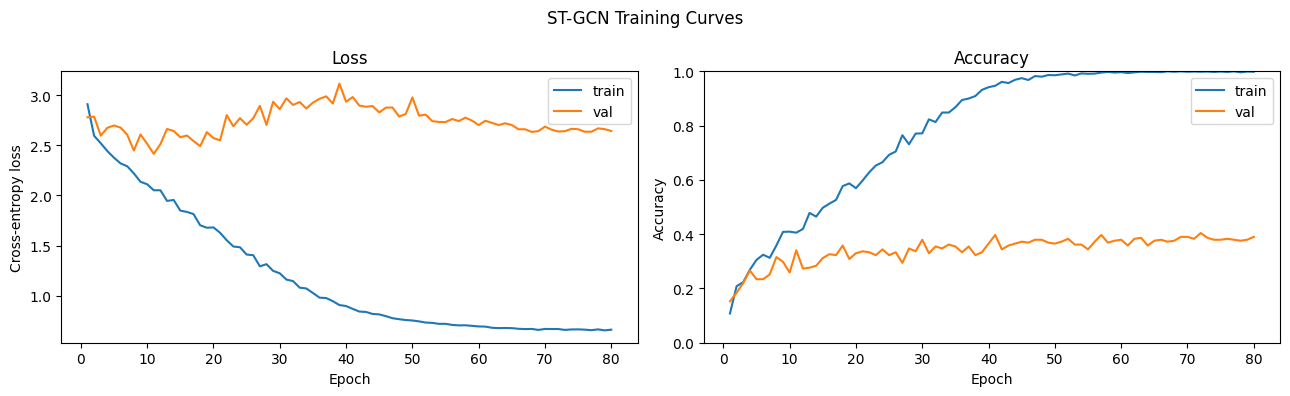

Saved to: /content/drive/MyDrive/14486346_Honours/outputs/stgcn_training_curves.png


In [13]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history['train_loss'], label='train')
axes[0].plot(epochs, history['val_loss'],   label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='train')
axes[1].plot(epochs, history['val_acc'],   label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('ST-GCN Training Curves', fontsize=12)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'stgcn_training_curves.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
logger.report_image('Training curves', 'ST-GCN', local_path=out)
plt.show()
print("Saved to:", out)

---
## Section 11 - Evaluation on Test Set

In [15]:
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val loss: {checkpoint['val_loss']:.4f})")

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(yb.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

stgcn_acc = accuracy_score(all_targets, all_preds)
stgcn_f1  = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

print()
print("ST-GCN TEST RESULTS")
print("-" * 40)
print(f"  Accuracy (weighted) : {stgcn_acc:.4f}  ({stgcn_acc*100:.1f}%)")
print(f"  F1-score (weighted) : {stgcn_f1:.4f}")

logger.report_scalar('Test', 'accuracy', stgcn_acc, 0)
logger.report_scalar('Test', 'f1_score', stgcn_f1,  0)

Loaded best model from epoch 11 (val loss: 2.4152)

ST-GCN TEST RESULTS
----------------------------------------
  Accuracy (weighted) : 0.3216  (32.2%)
  F1-score (weighted) : 0.3005


In [16]:
short_names = [n.replace('_', ' ') for n in class_names]
report = classification_report(
    all_targets, all_preds,
    target_names=short_names,
    zero_division=0
)
print(report)

report_path = os.path.join(OUTPUTS_DIR, 'stgcn_classification_report.txt')
with open(report_path, 'w') as f:
    f.write(f"ST-GCN Classification Report\n")
    f.write(f"Test accuracy : {stgcn_acc:.4f}\n")
    f.write(f"Test F1       : {stgcn_f1:.4f}\n\n")
    f.write(report)
print("Report saved to:", report_path)

                          precision    recall  f1-score   support

          00 Short Serve       0.46      0.73      0.56        15
   01 Cross Court Flight       0.10      0.07      0.08        15
                 02 Lift       0.35      0.44      0.39        16
            03 Tap Smash       0.11      0.07      0.08        15
                04 Block       0.40      0.13      0.20        15
            05 Drop Shot       0.17      0.24      0.20        17
            06 Push Shot       0.04      0.06      0.05        17
   07 Transitional Slice       0.25      0.20      0.22        15
                  08 Cut       0.22      0.25      0.24        16
            09 Rush Shot       0.57      0.53      0.55        15
      10 Defensive Clear       0.12      0.07      0.09        15
      11 Defensive Drive       0.41      0.73      0.52        15
                12 Clear       0.38      0.29      0.33        17
           13 Long Serve       0.42      0.76      0.54        17
         

---
## Section 12 - Confusion Matrix

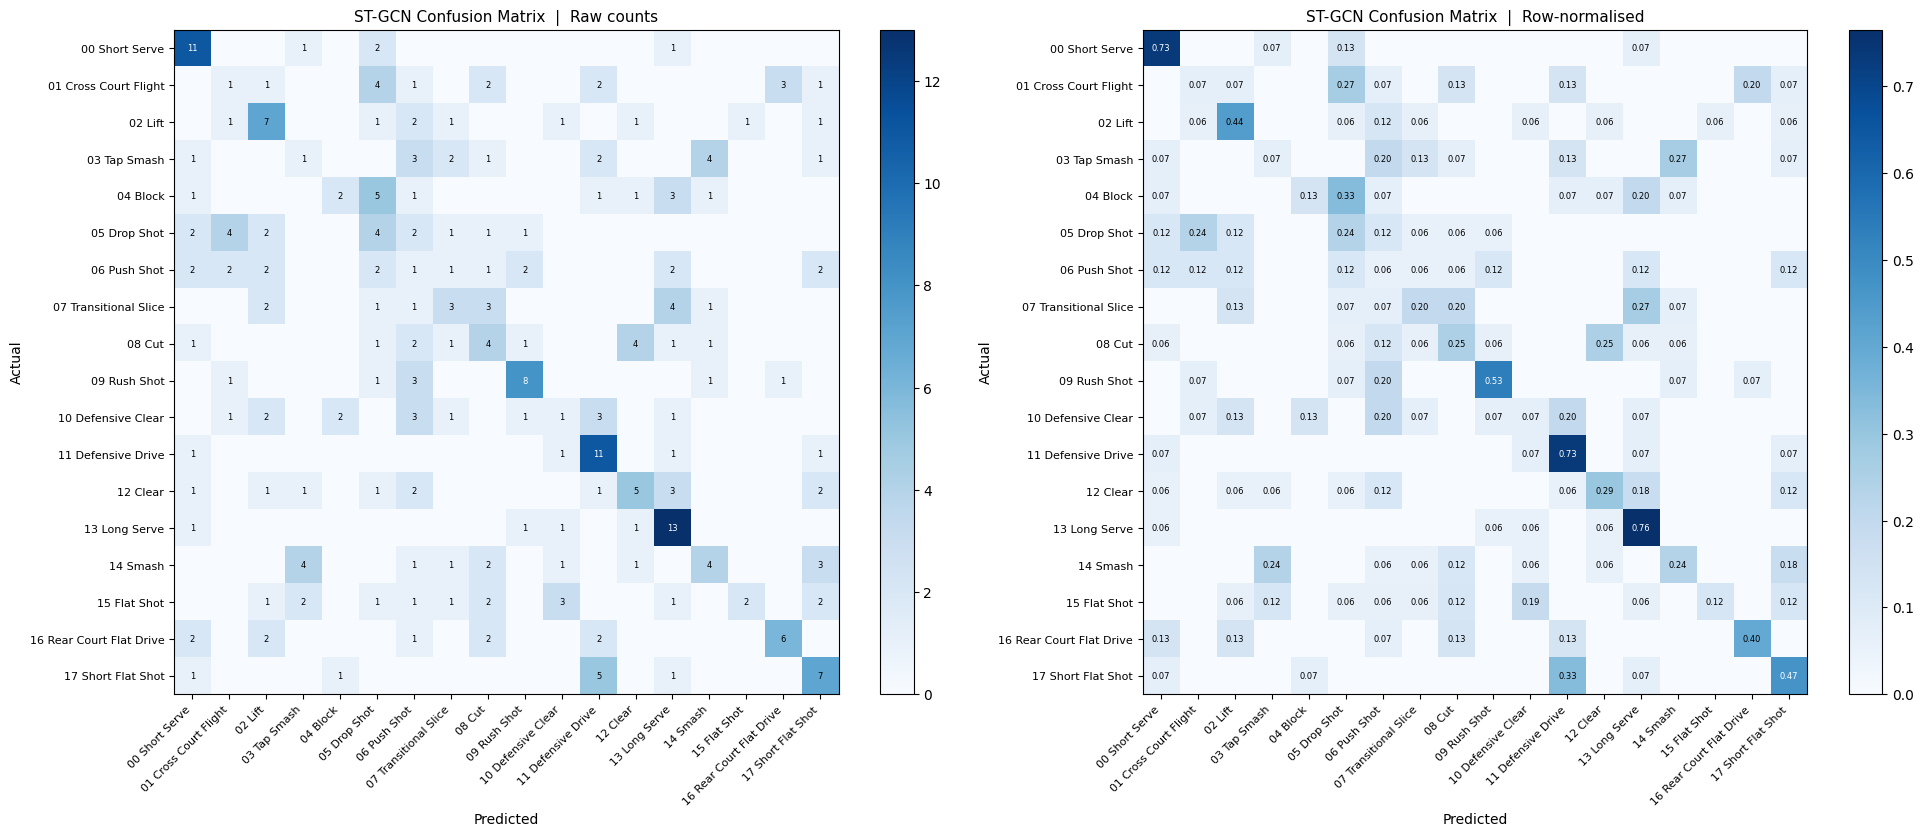

Saved to: /content/drive/MyDrive/14486346_Honours/outputs/stgcn_confusion_matrix.png


In [17]:
cm      = confusion_matrix(all_targets, all_preds)
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(np.float32), row_sum,
                    where=row_sum != 0)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, data, title, fmt in [
    (axes[0], cm,      'Raw counts',    'd'),
    (axes[1], cm_norm, 'Row-normalised', '.2f')
]:
    im = ax.imshow(data, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'ST-GCN Confusion Matrix  |  {title}', fontsize=11)
    plt.colorbar(im, ax=ax)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = data[i, j]
            if val > 0:
                tc = 'white' if val > data.max() * 0.6 else 'black'
                ax.text(j, i, format(val, fmt), ha='center', va='center',
                        fontsize=6, color=tc)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'stgcn_confusion_matrix.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
logger.report_image('Confusion matrix', 'ST-GCN', local_path=out)
plt.show()
print("Saved to:", out)

---
## Section 13 - Direct Comparison Against LSTM Baseline

Loads the saved LSTM results and puts both models side by side. This comparison goes directly into your thesis evaluation chapter.

In [18]:
# Load LSTM baseline results if available
lstm_report_path = os.path.join(OUTPUTS_DIR, 'lstm_classification_report.txt')
lstm_acc, lstm_f1 = None, None

if os.path.exists(lstm_report_path):
    with open(lstm_report_path) as f:
        lines = f.readlines()
    for line in lines:
        if 'Test accuracy' in line:
            lstm_acc = float(line.strip().split()[-1])
        if 'Test F1' in line:
            lstm_f1 = float(line.strip().split()[-1])

print("MODEL COMPARISON")
print("=" * 50)
print(f"  {'Model':<20} {'Accuracy':>10} {'F1 (weighted)':>15}")
print("-" * 50)

if lstm_acc is not None:
    print(f"  {'LSTM Baseline':<20} {lstm_acc*100:>9.1f}% {lstm_f1:>15.4f}")
else:
    print(f"  {'LSTM Baseline':<20} {'not found':>10} {'run NB03 first':>15}")

print(f"  {'ST-GCN':<20} {stgcn_acc*100:>9.1f}% {stgcn_f1:>15.4f}")
print("=" * 50)

if lstm_acc is not None:
    delta_acc = stgcn_acc - lstm_acc
    delta_f1  = stgcn_f1  - lstm_f1
    print(f"\n  ST-GCN improvement over LSTM:")
    print(f"    Accuracy : {delta_acc*100:+.1f} percentage points")
    print(f"    F1-score : {delta_f1:+.4f}")

# Log comparison to ClearML
if lstm_acc is not None:
    logger.report_scalar('Model comparison', 'LSTM accuracy',  lstm_acc,   0)
    logger.report_scalar('Model comparison', 'STGCN accuracy', stgcn_acc,  0)
    logger.report_scalar('Model comparison', 'LSTM F1',        lstm_f1,    0)
    logger.report_scalar('Model comparison', 'STGCN F1',       stgcn_f1,   0)

MODEL COMPARISON
  Model                  Accuracy   F1 (weighted)
--------------------------------------------------
  LSTM Baseline             32.2%          0.3159
  ST-GCN                    32.2%          0.3005

  ST-GCN improvement over LSTM:
    Accuracy : -0.0 percentage points
    F1-score : -0.0154


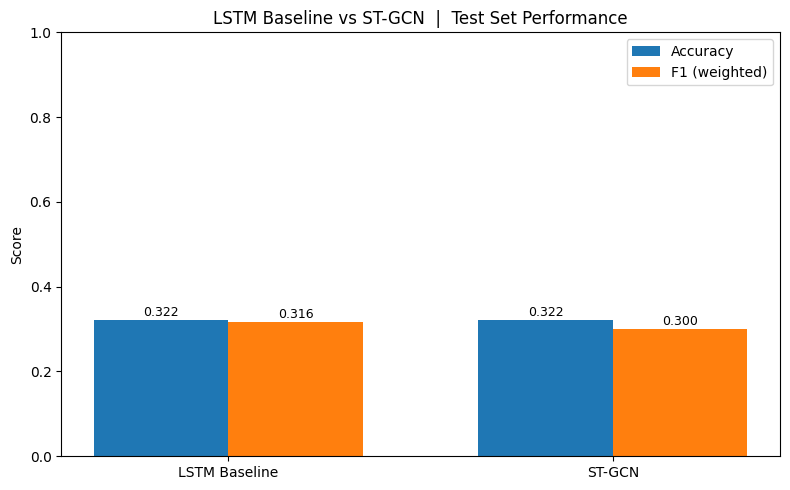

Saved to: /content/drive/MyDrive/14486346_Honours/outputs/model_comparison.png


In [19]:
# Bar chart comparing both models
models  = ['LSTM Baseline', 'ST-GCN']
accs    = [lstm_acc if lstm_acc else 0, stgcn_acc]
f1s     = [lstm_f1  if lstm_f1  else 0, stgcn_f1]

x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy')
bars2 = ax.bar(x + w/2, f1s,  w, label='F1 (weighted)')

ax.set_ylabel('Score')
ax.set_title('LSTM Baseline vs ST-GCN  |  Test Set Performance')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'model_comparison.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
logger.report_image('Model comparison', 'LSTM vs ST-GCN', local_path=out)
plt.show()
print("Saved to:", out)

---
## Section 14 - Close ClearML and Summary

In [20]:
task.upload_artifact('stgcn_best', artifact_object=best_model_path)
task.close()

print("NOTEBOOK 04 COMPLETE")
print("-" * 50)
print(f"  Clips used         : {len(X)}")
print(f"  Classes            : {NUM_CLASSES}")
print(f"  ST-GCN accuracy    : {stgcn_acc*100:.1f}%")
print(f"  ST-GCN F1          : {stgcn_f1:.4f}")
print(f"  Best model saved   : {best_model_path}")
print(f"  ClearML project    : BadmintonPoseAnalysis")
print()
print("Things to note before the next session:")
print("  - How much did ST-GCN improve over the LSTM baseline?")
print("  - Which classes are still being confused after ST-GCN?")
print("  - Is there a large train/val accuracy gap suggesting overfitting?")
print("  - Did the cosine LR schedule help vs the plateau scheduler?")
print()
print("Next steps depending on results:")
print("  - If accuracy is reasonable: begin hyperparameter tuning runs")
print("  - If flat-shot classes are still confused: consider merging them")
print("  - If overfitting is visible: increase dropout or add augmentation")
print("  - Final step: Notebook 05 - full dataset training + dashboard")

NOTEBOOK 04 COMPLETE
--------------------------------------------------
  Clips used         : 1882
  Classes            : 18
  ST-GCN accuracy    : 32.2%
  ST-GCN F1          : 0.3005
  Best model saved   : /content/drive/MyDrive/14486346_Honours/models/stgcn_best.pt
  ClearML project    : BadmintonPoseAnalysis

Things to note before the next session:
  - How much did ST-GCN improve over the LSTM baseline?
  - Which classes are still being confused after ST-GCN?
  - Is there a large train/val accuracy gap suggesting overfitting?
  - Did the cosine LR schedule help vs the plateau scheduler?

Next steps depending on results:
  - If accuracy is reasonable: begin hyperparameter tuning runs
  - If flat-shot classes are still confused: consider merging them
  - If overfitting is visible: increase dropout or add augmentation
  - Final step: Notebook 05 - full dataset training + dashboard
